# 3. Quantum optimization 101

**Reading time: about 45 minutes. Prerequisites: notebooks 1 and 2.**

This notebook explains what a quantum optimizer actually does with the matrix
`Q` you built in notebook 2. Nothing here requires physics. Four ideas carry the
whole subject:

1. A register of `n` qubits holds one number — an **amplitude** — for every one
   of the `2^n` bitstrings. For an islanding problem, that means one amplitude
   per possible split.
2. Measuring the register returns one bitstring, with probability equal to the
   squared magnitude of its amplitude.
3. A quantum algorithm reshapes those amplitudes so that low-cost bitstrings end
   up with large ones.
4. QAOA reshapes them with exactly two knobs per layer, and a classical
   optimizer turns the knobs.

The centrepiece is section 3.5: a contour map of the QAOA objective over its two
parameters. Everything before it builds the map, everything after it applies the
method at a size where the picture no longer fits on a page.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import qugrid as qg
from qugrid.network import Network
from qugrid.solvers.statevector import (
    apply_rx_all,
    diag_phase,
    expectation_diag,
    probabilities,
    uniform_state,
)

qg.viz.use_style()
np.set_printoptions(precision=4, suppress=True)

## 3.1 A two-bus system you can hold in your head

Nine buses give 512 possible splits, which is too many to print. So start with
two buses. Each bus carries its own generator and its own load, sized to match,
so either bus can run as a self-sufficient island. One tie line joins them.

In [2]:
bus = np.array(
    # bus type   Pd    Qd  Gs Bs area Vm Va baseKV zone Vmax Vmin
    [
        [1, 3, 90.0, 30.0, 0, 0, 1, 1.0, 0, 230, 1, 1.1, 0.9],
        [2, 2, 60.0, 20.0, 0, 0, 1, 1.0, 0, 230, 1, 1.1, 0.9],
    ]
)
gen = np.zeros((2, 21))
gen[0, :10] = [1, 90.0, 0.0, 100, -100, 1.0, 100, 1, 150, 0]
gen[1, :10] = [2, 60.0, 0.0, 100, -100, 1.0, 100, 1, 120, 0]
branch = np.zeros((1, 13))
branch[0, :11] = [1, 2, 0.01, 0.10, 0.0, 150, 150, 150, 0, 0, 1]
branch[:, 11], branch[:, 12] = -360.0, 360.0

two_bus = Network(baseMVA=100.0, bus=bus, gen=gen, branch=branch, name="two-bus")
print(two_bus)
print("net injection per bus [MW]:", two_bus.gen_p_per_bus() - two_bus.load_p)
print("tie line coupling 1/x    :", two_bus.edges()[0][2])

Network('two-bus': 2 buses, 1 branches, 2 generators, load 150.0 MW)
net injection per bus [MW]: [0. 0.]
tie line coupling 1/x    : 10.0


The islanding formulation weights three terms (notebook 1, section 1.2): cut
weight, squared power imbalance, and size balance. The library default for the
size-balance weight `beta` is deliberately small — it is a tie-breaker, not a
driver. On a two-bus graph that default makes “do not split” the minimum, which
is correct engineering and a dull first example. Setting `beta` explicitly makes
the balanced split the minimum, so there is something to find.

In [3]:
problem = qg.problems.Islanding(two_bus, beta=6.0)
qubo = problem.qubo
print("variables:", qubo.names)
print("Q =\n", qubo.q)
print("offset =", qubo.offset)

print(f"\n{'bitstring':>10} {'islands':>16} {'objective':>10} {'lines cut':>10} {'feasible':>9}")
for k in range(2**qubo.n):
    x = qubo.bits_from_index(k)
    decoded = problem.decode(x)
    side_a = [int(b) for b in np.flatnonzero(x == 0) + 1]
    side_b = [int(b) for b in np.flatnonzero(x == 1) + 1]
    label = f"A={side_a} B={side_b}"
    print(
        f"{''.join(map(str, x)):>10} {label:>16} {qubo.energy(x):>10.1f} "
        f"{decoded['n_cut']:>10} {str(problem.is_feasible(x)):>9}"
    )

variables: ['bus1', 'bus2']
Q =
 [[-14.  14.]
 [ 14. -14.]]
offset = 24.0

 bitstring          islands  objective  lines cut  feasible
        00    A=[1, 2] B=[]       24.0          0     False
        10      A=[2] B=[1]       10.0          1      True
        01      A=[1] B=[2]       10.0          1      True
        11    A=[] B=[1, 2]       24.0          0     False


Four assignments, two of them optimal at objective 10.0. `01` and `10` describe
the *same* physical split — bus 1 alone on one side, bus 2 on the other — with
the island labels swapped. This is a genuine symmetry of the formulation, not a
bug: nothing in the objective distinguishes island A from island B. Every
quantum result below shows both, splitting its probability evenly between them.

## 3.2 States and amplitudes

A classical register of 2 bits holds one of `00`, `01`, `10`, `11`. A quantum
register of 2 qubits holds a list of four complex numbers, one per bitstring,
called **amplitudes**. Write the register as `psi` and the amplitude of
bitstring `x` as `psi[x]`.

Two rules are all you need:

* **Measurement.** Reading the register returns exactly one bitstring. Bitstring
  `x` comes out with probability `|psi[x]|^2`. The probabilities sum to 1.
* **Interference.** Amplitudes are complex, so contributions to the same
  bitstring can cancel or reinforce. This is the only mechanism a quantum
  algorithm has, and it is what distinguishes it from a randomized classical one.

The starting state of QAOA is the **uniform superposition**: every bitstring
gets the same amplitude, so every split is equally likely.

One convention, stated once. Variable `i` is bit `i` of the basis-state index,
counting from the low end. QuGrid prints bitstrings with variable 0 leftmost, so
the printed string reads in the same order as `qubo.names`.

In [4]:
psi = uniform_state(2)
print(f"{'bitstring':>10} {'amplitude':>22} {'probability':>12} {'objective':>10}")
for k in range(4):
    x = qubo.bits_from_index(k)
    print(
        f"{''.join(map(str, x)):>10} {psi[k]:>22.4f} {abs(psi[k]) ** 2:>12.4f} "
        f"{qubo.energy(x):>10.1f}"
    )
print("\nprobabilities sum to", probabilities(psi).sum())

 bitstring              amplitude  probability  objective
        00         0.5000+0.0000j       0.2500       24.0
        10         0.5000+0.0000j       0.2500       10.0
        01         0.5000+0.0000j       0.2500       10.0
        11         0.5000+0.0000j       0.2500       24.0

probabilities sum to 1.0


Two qubits hold 4 amplitudes; nine qubits hold 512; fifty qubits hold about
`10^15`. Holding that list is free on a quantum computer and expensive on a
classical one, which is the whole reason for the field. QuGrid stores the list
explicitly in NumPy, which is why it stops at 22 qubits and why every number in
these notebooks is exact rather than sampled.

## 3.3 The Ising bridge

Quantum hardware does not accept a QUBO directly. It accepts an **Ising model**:
variables that take the values `+1` and `-1` instead of `0` and `1`. In power
system terms, the sign says which island a bus joins. The change of variables is

```
s = 1 - 2x     so   x = 0 -> s = +1,   x = 1 -> s = -1
```

and the objective becomes

```
H(s) = sum_{i<j} J_ij s_i s_j + sum_i h_i s_i + offset
```

`h_i` is the **local field** on variable `i` — a preference for one island over
the other, acting on that bus alone. `J_ij` is the **coupling** between `i` and
`j`. A positive `J_ij` is lowest when `s_i` and `s_j` have opposite signs, so it
pushes the two buses into different islands; a negative `J_ij` pulls them
together. The transformation is exact: every assignment keeps its objective
value.

In [5]:
ising = qubo.to_ising()
print("local fields h :", ising.h)
print("couplings J    :\n", ising.j)
print("offset         :", ising.offset)

print(f"\n{'bitstring':>10} {'spins':>10} {'QUBO':>8} {'Ising':>8}")
for k in range(4):
    x = qubo.bits_from_index(k)
    s = 1 - 2 * x
    print(f"{''.join(map(str, x)):>10} {str(s):>10} {qubo.energy(x):>8.1f} {ising.energy(s):>8.1f}")

local fields h : [0. 0.]
couplings J    :
 [[0. 7.]
 [0. 0.]]
offset         : 17.0

 bitstring      spins     QUBO    Ising
        00      [1 1]     24.0     24.0
        10    [-1  1]     10.0     10.0
        01    [ 1 -1]     10.0     10.0
        11    [-1 -1]     24.0     24.0


Both fields are zero, because neither bus is preferred, and the single coupling
is `J = +7`, which favours opposite islands — the tie line wants to be cut once
the size-balance term is strong enough to pay for it. The two columns of
objective values agree exactly, assignment by assignment.

`Ising.all_energies()` returns the objective of all `2^n` assignments as an
array, indexed the same way as the amplitude list. That array is the **cost
Hamiltonian**: for these problems the quantum operator that encodes the
objective is diagonal, meaning it assigns one number to each bitstring and
nothing more. Everything QAOA does with the objective, it does with this array.

In [6]:
cost = ising.all_energies()
print("cost Hamiltonian (one entry per bitstring):", cost)

cost Hamiltonian (one entry per bitstring): [24. 10. 10. 24.]


## 3.4 What QAOA does

QAOA — Quantum Approximate Optimization Algorithm, Farhi, Goldstone and Gutmann,
arXiv:1411.4028 — starts from the uniform superposition and applies `p` rounds
of two operations. Each round has two numbers, `gamma` and `beta`.

**Cost layer, angle `gamma`.** Multiply the amplitude of every bitstring `x` by
`exp(-i * gamma * cost(x))`. Expensive splits and cheap splits pick up different
phases. No probability changes at this step: only the phases move. This is the
step that reads the objective.

**Mixer layer, angle `beta`.** Apply `exp(-i * beta * X)` to every qubit, where
`X` is the bit-flip operator. This mixes each bitstring with its neighbours —
the assignments that differ in one bus. Because the neighbours now carry
different phases, their contributions add or cancel. This is the step that turns
the phase differences into probability differences.

Repeat `p` times, measure, read a bitstring. A classical optimizer adjusts the
`2p` angles to minimize the **expectation** — the average objective over the
output distribution, `sum_x P(x) * cost(x)`.

One implementation detail matters for reading the figures. QuGrid rescales the
cost array to the range `[0, 1]` before exponentiating, so that a useful `gamma`
sits in the same numeric range for every problem. Reported objective values stay
in the problem’s own units.

The entire algorithm is five lines.

In [7]:
spread = float(cost.max() - cost.min())
cost_scaled = (cost - cost.min()) / spread


def qaoa_state(gammas, betas) -> np.ndarray:
    """Depth-p QAOA state for this problem."""
    state = uniform_state(ising.n)
    for gamma, beta in zip(gammas, betas):
        diag_phase(state, -gamma * cost_scaled)  # cost layer
        apply_rx_all(state, ising.n, beta)  # mixer layer
    return state


trial = qaoa_state([1.0], [0.4])
print("amplitudes  :", np.round(trial, 4))
print("probabilities:", np.round(probabilities(trial), 4))
print("expectation :", round(expectation_diag(trial, cost), 4))

amplitudes  : [0.1882-0.6518j 0.0465-0.1938j 0.0465-0.1938j 0.1882-0.6518j]
probabilities: [0.4603 0.0397 0.0397 0.4603]
expectation : 22.8878


## 3.5 The landscape

With `p = 1` there are exactly two parameters, so the objective a classical
optimizer minimizes can be drawn in full. Evaluate the expectation on a grid of
`(gamma, beta)` values and contour it.

In [8]:
gamma_grid = np.linspace(0.0, 2 * np.pi, 121)
beta_grid = np.linspace(0.0, np.pi, 61)
landscape = np.array(
    [[expectation_diag(qaoa_state([g], [b]), cost) for g in gamma_grid] for b in beta_grid]
)
row, col = np.unravel_index(landscape.argmin(), landscape.shape)
print(f"grid minimum: gamma = {gamma_grid[col]:.4f}, beta = {beta_grid[row]:.4f}")
print(f"expectation there = {landscape.min():.4f}   (true optimum = {cost.min():.4f})")

grid minimum: gamma = 4.7124, beta = 0.4189
expectation there = 10.0383   (true optimum = 10.0000)


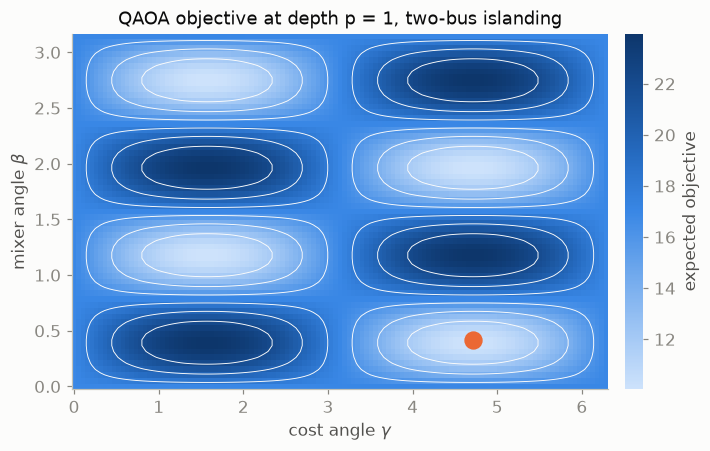

In [9]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
mesh = ax.pcolormesh(
    gamma_grid, beta_grid, landscape, cmap=qg.viz.sequential_cmap(), shading="auto"
)
ax.contour(gamma_grid, beta_grid, landscape, levels=8, colors=qg.viz.SURFACE, linewidths=0.6)
ax.plot(gamma_grid[col], beta_grid[row], "o", color=qg.viz.PALETTE[1], markersize=11)
bar = fig.colorbar(mesh, ax=ax, fraction=0.045, pad=0.03)
bar.set_label("expected objective")
bar.outline.set_visible(False)
ax.set_xlabel(r"cost angle $\gamma$")
ax.set_ylabel(r"mixer angle $\beta$")
ax.set_title("QAOA objective at depth p = 1, two-bus islanding")
ax.grid(False)
plt.show()

Dark is low. The surface is smooth and periodic — a consequence of the angles
entering through complex exponentials — and it has several basins of equal
depth, marked here by the orange point at one of them. A classical optimizer
started at a random point converges into whichever basin it lands in, which is
why `qg.solve(..., solver="qaoa")` uses several restarts by default. On larger
problems this landscape is what makes the optimization hard, and it is the
subject of a large part of the current QAOA literature.

At the best angles, depth 1 is enough to solve this instance completely.

In [10]:
best_state = qaoa_state([gamma_grid[col]], [beta_grid[row]])
for k in range(4):
    x = qubo.bits_from_index(k)
    print(f"  {''.join(map(str, x))}  probability {probabilities(best_state)[k]:.4f}")

library_result = qg.solve(problem, solver="qaoa", p=1, seed=0)
print()
print(library_result.summary())

  00  probability 0.0014
  10  probability 0.4986
  01  probability 0.4986
  11  probability 0.0014



QuGrid result | solver=qaoa | Islanding(n=2)
  objective          10
  feasible           yes
  gap vs reference   0%
  P(optimum)         1.000
  sizes              (1.0, 1.0)
  n_cut              1
  cut_weight         10
  island_power_mw    (0.0, 0.0)
  islands_connected  (1.0, 1.0)
  resources          wall_time_s=0.0878, n_qubits=2, p=1, evaluations=314, restarts=3, seed=0, expectation=10.0


The best grid point puts probability 0.4986 on each of the two optimal
assignments and 0.0014 on each of the other two. The probability is split evenly
between the optimal pair because they are the same physical split with the
island labels exchanged, exactly as section 3.1 predicted. The library solver
tunes the angles continuously instead of reading them off a 121-by-61 grid, and
reaches `P(optimum) = 1.000`.

## 3.6 Nine buses

The two-bus problem is solved at depth 1 because it has 4 assignments and one
cost scale. Return to case9: 9 qubits, 512 assignments, and a cost landscape
built from nine branch weights and a squared imbalance term. Sweep the depth and
measure three quantities at each depth.

In [11]:
case9 = qg.cases.case9()
islanding9 = qg.problems.Islanding(case9)
depths = [1, 2, 3, 4, 5]
runs = {}
for depth in depths:
    started = time.perf_counter()
    runs[depth] = qg.solve(islanding9, solver="qaoa", p=depth, restarts=6, maxiter=600, seed=1)
    print(
        f"p = {depth}: {time.perf_counter() - started:5.2f} s  "
        f"expectation = {runs[depth].resources['expectation']:8.3f}  "
        f"P(optimum) = {runs[depth].success_probability():.4f}  "
        f"objective of best sample = {runs[depth].objective:.4f}"
    )

uniform_success = 2 / 2**islanding9.n
print(f"\nuniform random guessing would give P(optimum) = {uniform_success:.4f}")

p = 1:  0.73 s  expectation =  128.837  P(optimum) = 0.0090  objective of best sample = 27.0512


p = 2:  1.09 s  expectation =  109.816  P(optimum) = 0.0103  objective of best sample = 27.0512


p = 3:  1.30 s  expectation =  106.446  P(optimum) = 0.0107  objective of best sample = 27.0512


p = 4:  1.56 s  expectation =   92.834  P(optimum) = 0.0128  objective of best sample = 27.0512


p = 5:  1.72 s  expectation =   94.875  P(optimum) = 0.0130  objective of best sample = 27.0512

uniform random guessing would give P(optimum) = 0.0039


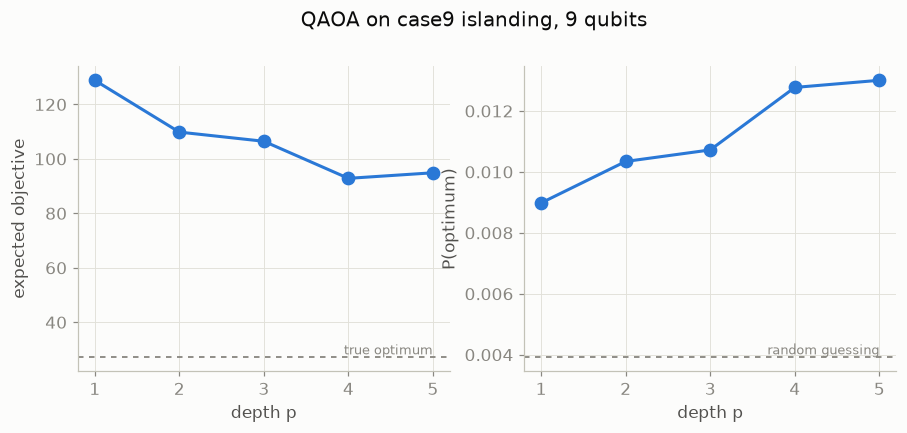

In [12]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.6))
left.plot(depths, [runs[d].resources["expectation"] for d in depths], "o-", color=qg.viz.PALETTE[0])
left.axhline(runs[1].reference["objective"], color=qg.viz.MUTED, lw=1.2, ls=(0, (3, 3)))
left.annotate(
    "true optimum", (depths[-1], runs[1].reference["objective"]),
    ha="right", va="bottom", fontsize=8.5, color=qg.viz.MUTED,
)
left.set_xlabel("depth p")
left.set_ylabel("expected objective")
left.set_xticks(depths)

right.plot(depths, [runs[d].success_probability() for d in depths], "o-", color=qg.viz.PALETTE[0])
right.axhline(uniform_success, color=qg.viz.MUTED, lw=1.2, ls=(0, (3, 3)))
right.annotate(
    "random guessing", (depths[-1], uniform_success),
    ha="right", va="bottom", fontsize=8.5, color=qg.viz.MUTED,
)
right.set_xlabel("depth p")
right.set_ylabel("P(optimum)")
right.set_xticks(depths)
fig.suptitle("QAOA on case9 islanding, 9 qubits", y=1.02)
plt.show()

The expected objective falls from 128.8 at depth 1 to 92.8 at depth 4, then
rises slightly at depth 5. That last step is an optimizer failure, not an
algorithm failure: depth 5 has 10 angles to tune and the same optimization
budget, so the classical search finds a worse point in a larger space. Reporting
it is the point — a depth sweep with a fixed budget measures the algorithm and
the optimizer together, and papers that show only the monotone part of such a
curve are hiding the harder half of the problem.

The probability of reading an optimal split rises from 0.90 percent to
1.30 percent, against 0.39 percent for uniform random guessing. That is a factor
of 3.3 over random after five layers, on a problem with 512 candidates.

The same movement is visible directly in the output distribution.

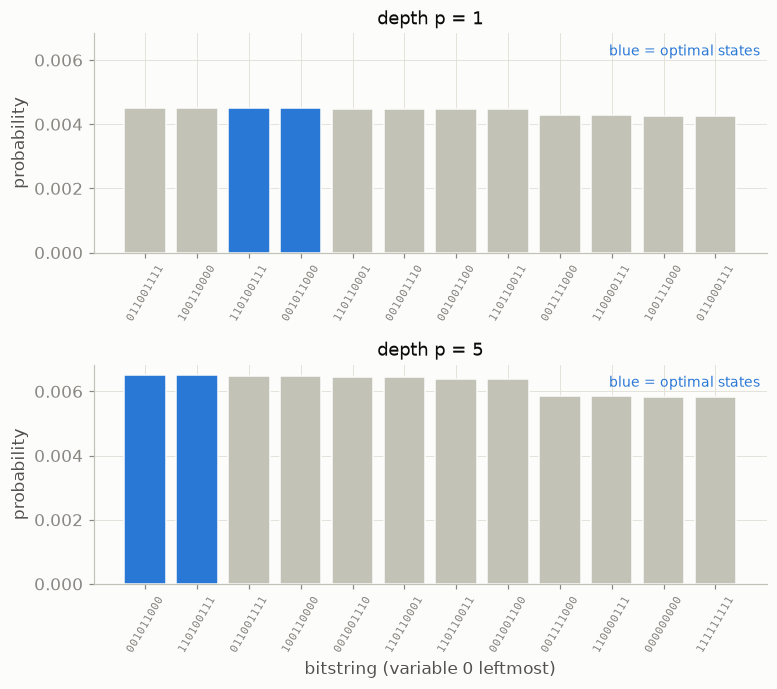

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.4), sharey=True)
for ax, depth in zip(axes, (1, 5)):
    qg.viz.plot_distribution(runs[depth], top=12, ax=ax)
    ax.set_title(f"depth p = {depth}")
axes[0].set_xlabel("")
plt.tight_layout()
plt.show()

Blue bars are optimal assignments. At depth 1 the twelve most likely bitstrings
carry nearly equal probability and the optimal pair is not at the front. At
depth 5 the optimal pair leads, and the gap to the rest has opened. The two
leading bitstrings are `001011000` and `110100111`, which are bitwise
complements — the same split with the island labels exchanged, the same symmetry
as in section 3.1.

## 3.7 What this is worth, measured

On this instance, exact enumeration and simulated annealing both return the true
optimum, and they do it faster than the QAOA simulation runs.

In [14]:
for solver, options in (("exact", {}), ("sa", {"seed": 0}), ("random", {"seed": 0})):
    started = time.perf_counter()
    result = qg.solve(islanding9, solver=solver, **options)
    print(
        f"{solver:>7}: {1000 * (time.perf_counter() - started):7.1f} ms   "
        f"objective {result.objective:8.4f}   gap {result.gap():.2e}"
    )
print(f"{'qaoa':>7}: {1000 * runs[5].resources['wall_time_s']:7.1f} ms   "
      f"objective {runs[5].objective:8.4f}   gap {runs[5].gap():.2e}")

  exact:     0.5 ms   objective  27.0512   gap -1.05e-15
     sa:    63.3 ms   objective  27.0512   gap -1.05e-15
 random:     0.4 ms   objective  27.0512   gap -1.05e-15
   qaoa:  1719.7 ms   objective  27.0512   gap -1.05e-15


State this plainly whenever you report a result like the one above: **at nine
buses, classical methods win, and by a wide margin.** Enumeration is exact and
takes well under a millisecond. Simulated annealing is exact here too. Uniform
random sampling of 1000 bitstrings out of 512 also finds the optimum. Nothing in
section 3.6 is evidence of a quantum advantage, and presenting it as such is the
most common error in the applied literature.

What the exercise is for:

* **Mechanics.** You have now seen where the objective enters the circuit, what
  the two angles do, what the landscape looks like, and how the answer arrives
  as a distribution rather than a value. That transfers unchanged to problem
  sizes nobody can enumerate.
* **Resource accounting.** `result.resources` reports qubits, depth, and
  evaluation counts. Those are the numbers that decide whether a formulation is
  reachable on a given machine, and they can be computed today for problems that
  cannot be run today.
* **Encoding research.** The gap between a QUBO optimum and the true engineering
  optimum (notebook 2, section 2.5) is set by the encoding alone, and improving
  it needs no quantum hardware at all.
* **Honest baselines.** Simulated annealing runs on the same `Q`. Any claim
  about a quantum optimizer on a power system problem has to survive that
  comparison, which is why QuGrid ships it as a first-class solver.

For a published example of this workflow on unit commitment, see A. Koretsky et
al., “Adapting Quantum Approximation Optimization Algorithm (QAOA) for Unit
Commitment”, IEEE International Conference on Quantum Computing and Engineering,
2021, arXiv:2110.12624 — the formulation that `qg.problems.UnitCommitment`
follows.

## 3.8 Summary

* A quantum register holds one amplitude per bitstring; measurement returns one
  bitstring with probability equal to the squared magnitude of its amplitude.
* A QUBO becomes an Ising model by `s = 1 - 2x`. Local fields prefer an island
  for one bus; couplings prefer agreement or disagreement between two buses.
* QAOA alternates a cost layer, which writes the objective into phases, and a
  mixer layer, which converts those phases into probabilities. Depth `p` costs
  `2p` classical parameters.
* Success probability and expected objective are different measurements. Report
  both, with the random-guessing baseline beside them.

Notebook 4 leaves combinatorial optimization for the other major family of
quantum algorithms: linear system solvers, applied to power flow.